<a href="https://colab.research.google.com/github/3dgarxx3/Mineria_Datos/blob/main/IA_1_Verano.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv('/content/bottle1.csv')
df_binary = df[['Salnty','T_degC']]

df_binary.columns = ['Sal','Temp']
df_binary500 = df_binary[:][:500]

df_binary500.fillna(method = 'ffill', inplace=True)
df_binary500.dropna(inplace=True)
sns.lmplot(x='Sal',y='Temp',data=df_binary500,order=2,ci = None)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/bottle1.csv'

In [ ]:
X = np.array(df_binary500['Sal']).reshape(-1,1)
y = np.array(df_binary500['Temp']).reshape(-1,1)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25)
regr = LinearRegression()
regr.fit(X_train,y_train)
print(regr.score(X_test,y_test))

In [ ]:
y_pred = regr.predict(X_test)
plt.scatter(X_test,y_test,color='black')
plt.plot(X_test,y_pred,color='blue',linewidth=3)
plt.show()

In [ ]:
X_New = np.array([[5],[6]])
prediccion = regr.predict(X_New)
print(prediccion)

In [ ]:
import pandas as pd
datos = pd.read_csv('/content/housing.csv',usecols = ['longitude','latitude','median_house_value'])
datos.head()
import seaborn as sns
sns.scatterplot(data = datos,x='longitude',y='latitude',hue='median_house_value')

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(datos[['latitude','longitude']],
                                                 datos[['median_house_value']],test_size=0.33,random_state=0)

In [ ]:
from sklearn import preprocessing
X_train_norm = preprocessing.normalize(x_train)
X_test_norm = preprocessing.normalize(x_test)

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3,random_state=0,n_init='auto')
kmeans.fit(X_train_norm)

sns.scatterplot(data = x_train, x ='longitude', y='latitude', hue=kmeans.labels_)

sns.boxplot(x = kmeans.labels_, y = y_train['median_house_value'])

Practica 6

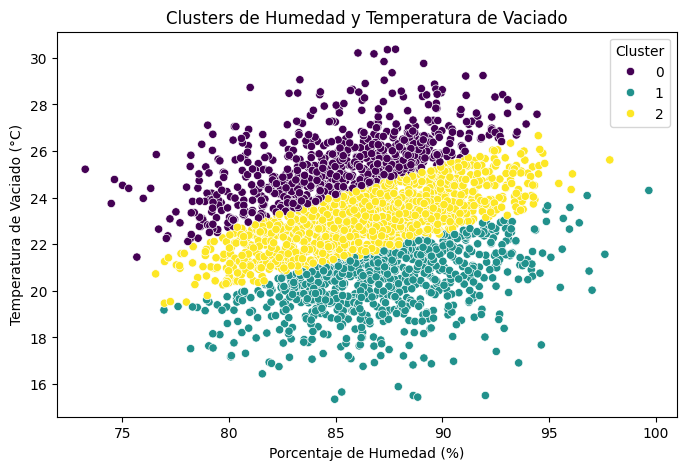

/tmp/ipykernel_14960/510322819.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


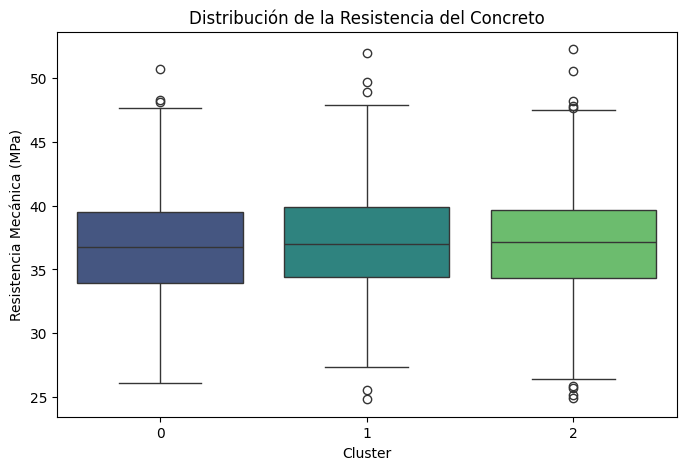

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.cluster import KMeans

datos = pd.read_csv('/content/TempHumedad_Cons2026.csv')

columnas_interes = ['Pour_Temp_degC', 'Moisture_Pct', 'Strength_MPa']
datos_limpios = datos[columnas_interes].dropna().copy()

x_train, x_test, y_train, y_test = train_test_split(
    datos_limpios[['Pour_Temp_degC', 'Moisture_Pct']],
    datos_limpios[['Strength_MPa']],
    test_size=0.33,
    random_state=0
)

X_train_norm = preprocessing.normalize(x_train)
X_test_norm = preprocessing.normalize(x_test)

kmeans = KMeans(n_clusters=3, random_state=0, n_init='auto')
kmeans.fit(X_train_norm)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=x_train,
    x='Moisture_Pct',
    y='Pour_Temp_degC',
    hue=kmeans.labels_,
    palette='viridis'
)
plt.title('Clusters de Humedad y Temperatura de Vaciado')
plt.xlabel('Porcentaje de Humedad (%)')
plt.ylabel('Temperatura de Vaciado (°C)')
plt.legend(title='Cluster')
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(
    x=kmeans.labels_,
    y=y_train['Strength_MPa'],
    palette='viridis'
)
plt.title('Distribución de la Resistencia del Concreto')
plt.xlabel('Cluster')
plt.ylabel('Resistencia Mecánica (MPa)')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

# 1. Leer archivo
data = pd.read_csv("spam.csv", columns = ['Type', 'Message'])



# Convertir etiquetas (variables categoricas) a binario (0 = Ham, 1 = Spam)
df['Type'] = df['Type'].map({'ham': 0, 'spam': 1})

# 2. Datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    df['text'],
    df['label'],
    test_size=0.33,
    random_state=42
)


# CountVectorizer = convertir texto a matriz de tokens
# Uso de distribución MultinomialNB  para Naive Bayes.
clf_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(stop_words='english')),
    ('nb_classifier', MultinomialNB())
])

# 4. Entrenar modelo
clf_pipeline.fit(X_train, y_train)

# 5. Evaluar modelo
y_pred = clf_pipeline.predict(X_test)

print(f"Precisión: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classificación:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

# 6. Prueba
custom_emails = [
    "Hello, let's schedule our quarterly performance review next Tuesday.",
    "CONGRATULATIONS! You won a luxury tropical holiday vacation. Text CLAIM to 88442"
]

predictions = clf_pipeline.predict(custom_emails)

print("\n--- Prediciones de nuevos emails ---")
for email, pred in zip(custom_emails, predictions):
    status = "SPAM" if pred == 1 else "NOT SPAM"
    print(f"Email: '{email}' -> Resultado: {status}")

TypeError: read_csv() got an unexpected keyword argument 'columns'

#Parcial 2

## Practica 1

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

np.random.seed(42) # Semilla para que los resultados sean replicables
N = 1000           # Número de muestras

X = np.random.uniform(-2, 2, (N, 3))

combinacion_lineal = 0.2 + 0.3 * X[:, 0] + 0.4 * X[:, 1] - 0.12 * X[:, 2]
y = (combinacion_lineal > 0).astype(int)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


class Neurona:
    def __init__(self, lr=0.5, epochs=2000):
        self.lr = lr
        self.epochs = epochs

        self.w = np.random.randn(3)
        self.b = np.random.randn()

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        z = np.dot(X, self.w) + self.b
        return self.sigmoid(z)

    def ajustar_w(self, X, y):
        m = X.shape[0]

        for epoch in range(self.epochs):
            y_hat = self.forward(X)

            error = y_hat - y

            dw = np.dot(X.T, error) / m
            db = np.sum(error) / m

            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, X):
        y_hat = self.forward(X)
        return (y_hat >= 0.5).astype(int)

    def evaluar_precision(self, X, y):
        predicciones = self.predict(X)
        accuracy = np.mean(predicciones == y)
        return accuracy * 100


mi_neurona = Neurona(lr=0.5, epochs=2000)

print("Entrenando a la neurona...")
mi_neurona.ajustar_w(X_train, y_train)
print("¡Entrenamiento completado!\n")

# 5. Imprimir la precisión de la neurona
precision_entrenamiento = mi_neurona.evaluar_precision(X_train, y_train)
precision_prueba = mi_neurona.evaluar_precision(X_test, y_test)

print(f"Precisión en Entrenamiento: {precision_entrenamiento:.2f}%")
print(f"Precisión en Prueba: {precision_prueba:.2f}%\n")

# 6. Imprimir el valor de los parámetros de aprendizaje obtenidos
print("Parámetros de aprendizaje finales obtenidos:")
print(f" Peso w1 (para x1): {mi_neurona.w[0]:.4f}")
print(f" Peso w2 (para x2): {mi_neurona.w[1]:.4f}")
print(f" Peso w3 (para x3): {mi_neurona.w[2]:.4f}")
print(f" Sesgo b (Bias):    {mi_neurona.b:.4f}")

Entrenando a la neurona...
¡Entrenamiento completado!

Precisión en Entrenamiento: 99.50%
Precisión en Prueba: 98.50%

Parámetros de aprendizaje finales obtenidos:
 Peso w1 (para x1): 6.0783
 Peso w2 (para x2): 8.2093
 Peso w3 (para x3): -2.2573
 Sesgo b (Bias):    3.9473


In [ ]:
import cv2
import numpy as np

# 1. Nombre de tu archivo (asegúrate de que termine en .jpg)
nombre_archivo = '/content/3.jpg'

# 2. Cargar la imagen usando OpenCV
img = cv2.imread(nombre_archivo)

if img is None:
    print(f"❌ Error: No se pudo encontrar o cargar el archivo '{nombre_archivo}'.")
    print("Por favor, asegúrate de haber subido la imagen al menú lateral de Colab.")
else:
    # 3. Convertir la imagen a escala de grises
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 4. Cambiar el tamaño a exactamente 28 x 28 píxeles
    # INTER_AREA es el método recomendado por OpenCV para encoger imágenes
    img_28x28 = cv2.resize(gray_img, (28, 28), interpolation=cv2.INTER_AREA)

    # Guardar la nueva versión en miniatura por si quieres revisarla
    cv2.imwrite('numero_procesado_28x28.jpg', img_28x28)
    print("✅ Imagen cargada, pasada a escala de grises y reajustada a 28x28 píxeles.")

    # 5. Guardar la matriz en un archivo .csv
    # Los valores se guardan como enteros (0 a 255) separados por comas
    np.savetxt('matriz_numero.csv', img_28x28, delimiter=',', fmt='%d')
    print("✅ Matriz guardada con éxito en 'matriz_numero.csv'")

    # Extra: Mostrar la forma final de la matriz para confirmar
    print(f"\n📊 Forma de la matriz: {img_28x28.shape} (Filas, Columnas)")

✅ Imagen cargada, pasada a escala de grises y reajustada a 28x28 píxeles.
✅ Matriz guardada con éxito en 'matriz_numero.csv'

📊 Forma de la matriz: (28, 28) (Filas, Columnas)


In [ ]:
import tensorflow as tf

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical

(x_train,y_train),(x_test,y_test) = datasets.mnist.load_data()

x_train,x_test = x_train/255.0,x_test/255.0
x_train = x_train.reshape((x_train.shape[0],28,28,1))
x_test = x_test.reshape((x_test.shape[0],28,28,1))

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
model = models.Sequential()
model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Flatten())
model.add(layers.Dense(64,activation='relu'))
model.add(layers.Dense(10,activation='softmax'))

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.fit(x_train,y_train,epochs=5,batch_size=64,validation_data=(x_test,y_test))
test_loss,test_acc = model.evaluate(x_test,y_test)
print(f"Precisión en el conjunto de prueba: {test_acc*100:.2f}%")

predictions = model.predict(x_test[:5])
print("predicted labels:",predictions.argmax(axis=1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 33s 32ms/step - accuracy: 0.9476 - loss: 0.1753 - val_accuracy: 0.9814 - val_loss: 0.0574
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 28s 30ms/step - accuracy: 0.9841 - loss: 0.0528 - val_accuracy: 0.9853 - val_loss: 0.0435
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - accuracy: 0.9885 - loss: 0.0376 - val_accuracy: 0.9884 - val_loss: 0.0381
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - accuracy: 0.9907 - loss: 0.0289 - val_accuracy: 0.9880 - val_loss: 0.0355
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - accuracy: 0.9929 - loss: 0.0211 - val_accuracy: 0.9898 - val_loss: 0.0322
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9898 - loss: 0.0322
Precisión en el conjunto de prueba: 98.98%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
predicted labels: [7 2 1 0 4]
